In [58]:
#IMPORT THE REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [59]:
#IMPORTING DATASET
df = pd.read_csv(r"C:\Users\admin\Downloads\ML_Loan_Project\Data\loan_prediction_dataset.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.columns)

   Age  Income  Credit_Score  Loan_Amount  Loan_Term Employment_Status  \
0   56   81788           334        15022         48          Employed   
1   69  102879           781        21013         24     Self-Employed   
2   46   58827           779        39687         60     Self-Employed   
3   32  127188           364        16886         24        Unemployed   
4   60   25655           307        26256         36        Unemployed   

   Loan_Approved  
0              0  
1              1  
2              0  
3              0  
4              0  
(2000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                2000 non-null   int64
 1   Income             2000 non-null   int64
 2   Credit_Score       2000 non-null   int64
 3   Loan_Amount        2000 non-null   int64
 4   Loan_Term          2000 non-null   int64
 5   Employmen

In [60]:
#CHECKING FOR NULL VALUES
print(df.isnull().sum())


Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64


In [61]:
#LABEL ENCODING
le = LabelEncoder()

df['Employment_Status'] = le.fit_transform(df['Employment_Status'])


In [62]:
#SEPERATE FEATURE AND TARGET
x = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']
print(x)
print(y)

      Age  Income  Credit_Score  Loan_Amount  Loan_Term  Employment_Status
0      56   81788           334        15022         48                  0
1      69  102879           781        21013         24                  1
2      46   58827           779        39687         60                  1
3      32  127188           364        16886         24                  2
4      60   25655           307        26256         36                  2
...   ...     ...           ...          ...        ...                ...
1995   63   87580           761        29716         48                  0
1996   67   27368           695        13601         36                  0
1997   69  105436           636        37018         36                  1
1998   24  116136           441         9061         48                  0
1999   20   66403           616         9609         12                  2

[2000 rows x 6 columns]
0       0
1       1
2       0
3       0
4       0
       ..
1995    1
1996 

In [63]:
#FEATURE SCALING
scaler = StandardScaler()

X = scaler.fit_transform(x)
print(x)

      Age  Income  Credit_Score  Loan_Amount  Loan_Term  Employment_Status
0      56   81788           334        15022         48                  0
1      69  102879           781        21013         24                  1
2      46   58827           779        39687         60                  1
3      32  127188           364        16886         24                  2
4      60   25655           307        26256         36                  2
...   ...     ...           ...          ...        ...                ...
1995   63   87580           761        29716         48                  0
1996   67   27368           695        13601         36                  0
1997   69  105436           636        37018         36                  1
1998   24  116136           441         9061         48                  0
1999   20   66403           616         9609         12                  2

[2000 rows x 6 columns]


In [64]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [65]:
# PIPELINE
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])


In [66]:
# HYPERPARAMETER TUNING
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)


Best Parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}


In [67]:
# PREDICTION
y_pred = best_model.predict(X_test)


In [68]:
# EVALUATION
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
[[322   0]
 [  0  78]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00        78

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [69]:
#CROSS VALIDATION
scores = cross_val_score(best_model, X, y, cv=5)

print("\nCross Validation Accuracy:", scores.mean())


Cross Validation Accuracy: 0.9974999999999999


In [70]:
#FEATURE IMPORTANCE
rf_model = best_model.named_steps["rf"]

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", feature_importance)



Feature Importance:
              Feature  Importance
2       Credit_Score    0.492905
3        Loan_Amount    0.285272
1             Income    0.197193
0                Age    0.016237
4          Loan_Term    0.005586
5  Employment_Status    0.002807


In [ ]:
#TRAIN THE MODEL
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
#MAKE PREDICTION
y_pred = model.predict(X_test)

In [ ]:
#EVALUATE THE MODEL
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))



Accuracy: 1.0
[[322   0]
 [  0  78]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       322
           1       1.00      1.00      1.00        78

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



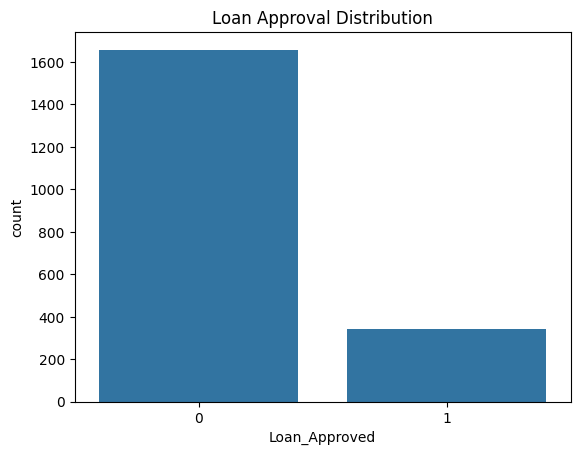

In [ ]:
#VISUALIZATION
#COUNT PLOT
sns.countplot(x='Loan_Approved', data=df)
plt.title("Loan Approval Distribution")
plt.show()


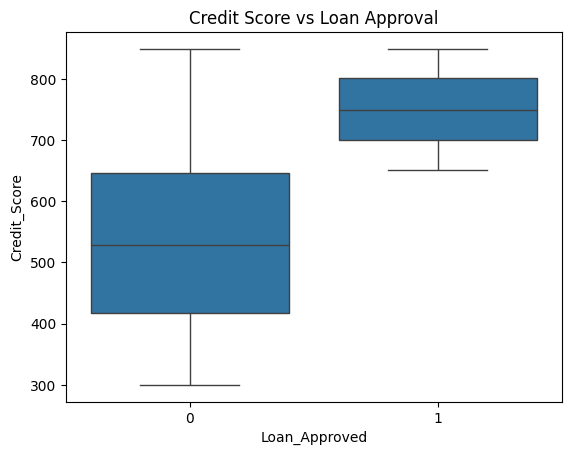

In [72]:
#BOX PLOT
sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df)
plt.title("Credit Score vs Loan Approval")
plt.show()
